## The Decision Tree Model

Decision Tree model. It is one of the simplest nonlinear machine learning models.

It all starts with a dataset in which you have a target variable and multiple explanatory variables. Now a huge number of splits are possible, but you need to choose 
one. The first split should be the split that would obtain `the lowest Mean Squared Error`. In the end, even a model with only one split would be able to be used as a predictive 
model.

We’ll be working with data that come from a bike-sharing company. We can download the data from the UCI machine learning archives over here: ***`https://archive.ics.uci.edu/ml/datasets/bike+sharing+dataset`***.
This will be a difficult example. In this dataset, we’ll be predicting the number of rental bike users per day. And this will depend strongly on the weather. The weather is hard to predict, and if our forecast has a strong correlation with the weather, it will be a big challenge.

In [1]:
#nImport the bike data
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv('../database/bike+sharing+dataset/day.csv')
data

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796


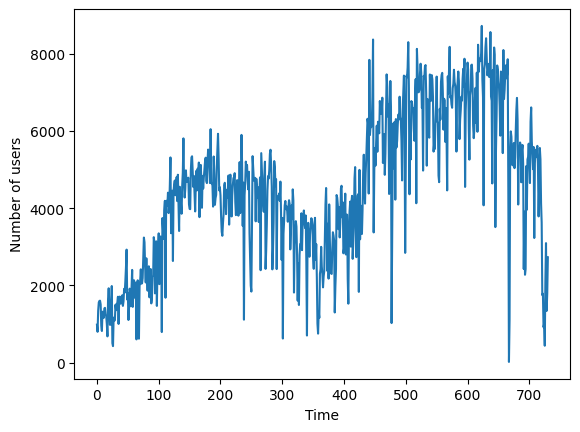

In [2]:
ax = data['cnt'].plot()
ax.set_ylabel('Number of users')
ax.set_xlabel('Time')
plt.show()

There is a difficult trend to be estimated. There is also a lot of day-to-day variation. When we look at the dataset, 
we can see that there are a lot of data on weather. This is going to be the challenge: the number of bike-sharing users depends strongly on the day’s weather, but the weather is 
not something that we can know in advance.

The only thing you can do in such cases is to try and do a lot of feature engineering to create many valuable variables for the model.

The total list of explanatory values is as follows:
* Original variable ‘season’: (1:spring, 2:summer, 3:fall, 4:winter)
* Original variable ‘yr’: The year
* Original variable ‘mnth’: The month
* Original variable ‘holiday’: Whether the day is a holiday
* Original variable ‘weekday’: The day of the week
* Original variable ‘workingday’: Whether the day is a holiday/weekend or a working day
* The 7 last days of ‘cnt’: An autoregressive component for the number of users
* The 7 last days of ‘weathersit’: The weather, from 4 (very bad weather) to 1 (good weather)
* The 7 last days of ‘temperature’
* The 7 last days of ‘humidity’